[SOAL A] – Proses Pengolahan dan Pembersihan Data
1. Penggabungan Dataset & Mengetahui Jumlah Seluruh Baris
Penjelasan

Proses penggabungan beberapa dataset yang terpisah secara vertikal (ditumpuk atas-bawah) dilakukan menggunakan pustaka Pandas melalui fungsi pd.concat(). Fungsi ini digunakan untuk menyatukan beberapa DataFrame yang memiliki struktur kolom yang sama menjadi satu dataset utuh sehingga data transaksi dari berbagai cabang dapat dianalisis secara bersamaan.

Setelah proses penggabungan selesai, jumlah seluruh baris data dapat diketahui menggunakan atribut .shape[0]. Properti ini digunakan untuk mengambil total indeks baris pada DataFrame tanpa harus menghitungnya secara manual. Selain jumlah baris, jumlah kolom juga dapat diketahui menggunakan .shape[1].

In [1]:
import pandas as pd

# Membaca dataset dari GitHub
url_yk = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_yk.csv"
url_mgl = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_mgl.csv"

df_yk = pd.read_csv(url_yk)
df_mgl = pd.read_csv(url_mgl)

# Menggabungkan dataset
df_gabungan = pd.concat([df_yk, df_mgl], ignore_index=True)

# Menghitung jumlah baris dan kolom
jumlah_baris = df_gabungan.shape[0]
jumlah_kolom = df_gabungan.shape[1]

# Menampilkan hasil
print(f"Jumlah seluruh baris setelah digabung: {jumlah_baris} baris")
print(f"Jumlah kolom setelah digabung: {jumlah_kolom} kolom")

Jumlah seluruh baris setelah digabung: 23849 baris
Jumlah kolom setelah digabung: 6 kolom


2. Proses Removing Outliers pada Kolom Harga
Penjelasan

Outliers merupakan data ekstrem yang nilainya terlalu tinggi atau terlalu rendah dibandingkan data lainnya. Pada kolom harga, outliers dapat muncul akibat kesalahan input transaksi atau gangguan sistem pencatatan data.

Metode yang digunakan untuk mendeteksi outliers adalah IQR (Interquartile Range). Langkah-langkahnya yaitu:
Menghitung Kuartil 1 (Q1)
Menghitung Kuartil 3 (Q3)
Menghitung IQR dengan rumus:

IQR=Q3−Q1

Menentukan batas bawah dan batas atas:

Batas Bawah=Q1−1.5×IQR

Batas Atas=Q3+1.5×IQR

Data yang berada di luar rentang tersebut dianggap outlier dan dihapus melalui proses filtering sehingga dataset menjadi lebih bersih dan homogen.

In [3]:
# Menghitung Q1, Q3, dan IQR
Q1 = df_gabungan['harga'].quantile(0.25)
Q3 = df_gabungan['harga'].quantile(0.75)

IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Filtering data tanpa outlier
df_clean_outlier = df_gabungan[
    (df_gabungan['harga'] >= batas_bawah) &
    (df_gabungan['harga'] <= batas_atas)
]

print(f"Jumlah data sebelum outlier dihapus: {len(df_gabungan)}")
print(f"Jumlah data setelah outlier dihapus: {len(df_clean_outlier)}")

Jumlah data sebelum outlier dihapus: 23849
Jumlah data setelah outlier dihapus: 21349


3. Checking Missing Value Data dan Jumlah Missing Value
Penjelasan

Missing value merupakan kondisi ketika terdapat data kosong atau tidak terisi pada suatu kolom di dalam dataset. Data kosong dapat memengaruhi kualitas analisis dan menyebabkan hasil pengolahan data menjadi kurang akurat. Oleh karena itu, proses pengecekan missing value perlu dilakukan sebelum tahap analisis lebih lanjut.

Pengecekan missing value dilakukan menggunakan fungsi .isnull() pada library Pandas. Fungsi ini akan memeriksa seluruh isi DataFrame dan menghasilkan nilai:

True jika data kosong
False jika data terisi

Selanjutnya fungsi .sum() digunakan untuk menghitung jumlah data kosong pada setiap kolom. Untuk mengetahui total keseluruhan missing value di dalam dataset, digunakan kombinasi .sum().sum() sehingga seluruh data kosong dapat dihitung secara akumulatif.

Melalui proses ini, analis dapat menentukan tindakan selanjutnya terhadap data kosong, seperti menghapus data tersebut atau melakukan imputasi data menggunakan nilai rata-rata, median, maupun metode lainnya.

In [4]:
# Mengecek jumlah missing value per kolom
missing_per_kolom = df_gabungan.isnull().sum()

# Menghitung total missing value seluruh dataset
total_missing = df_gabungan.isnull().sum().sum()

# Menampilkan hasil pengecekan
print("=== Missing Value Per Kolom ===")
print(missing_per_kolom)

print("\nTotal Missing Value :", total_missing)

=== Missing Value Per Kolom ===
tanggal     40
kode        37
nama       108
jumlah     107
harga      106
area         0
dtype: int64

Total Missing Value : 398


4. Checking Duplikasi dan Deduplikasi Dataset
Penjelasan

Data duplikat merupakan baris data yang memiliki isi sama persis pada seluruh kolom. Duplikasi data dapat terjadi akibat kesalahan input transaksi, proses impor data berulang, maupun gangguan sistem penyimpanan data.

Pengecekan jumlah data duplikat dilakukan menggunakan fungsi .duplicated().sum(). Fungsi .duplicated() akan memeriksa setiap baris data dan menandai apakah baris tersebut merupakan duplikasi dari baris sebelumnya. Selanjutnya .sum() digunakan untuk menghitung total data duplikat yang ditemukan.

Setelah jumlah data duplikat diketahui, proses deduplikasi dilakukan menggunakan fungsi .drop_duplicates(). Fungsi ini akan menghapus data ganda dan secara default mempertahankan data pertama (keep='first') sehingga dataset menjadi lebih bersih, valid, dan siap digunakan dalam proses analisis maupun visualisasi data.

In [5]:
# Mengecek jumlah data duplikat
jumlah_duplikat = df_gabungan.duplicated().sum()

# Menghapus data duplikat
df_final = df_gabungan.drop_duplicates()

# Menampilkan hasil
print(f"Jumlah data awal : {len(df_gabungan)} baris")
print(f"Jumlah data duplikat : {jumlah_duplikat} baris")
print("------------------------------------------------")
print(f"Jumlah data setelah deduplikasi : {len(df_final)} baris")

Jumlah data awal : 23849 baris
Jumlah data duplikat : 7502 baris
------------------------------------------------
Jumlah data setelah deduplikasi : 16347 baris


[SOAL B] Visualisasi Data dengan Grafik Line Chart
Penjelasan

Visualisasi data dilakukan untuk melihat tren penjualan produk Teh Celup Melati dari Bulan 1 sampai Bulan 12 sesuai ketentuan NIM 12221956.

Tahap pertama dilakukan dengan mengubah kolom tanggal transaksi menjadi format datetime menggunakan fungsi pd.to_datetime(). Setelah itu, data bulan transaksi diambil menggunakan atribut .dt.month sehingga setiap transaksi dapat dikelompokkan berdasarkan bulan.

Selanjutnya dataset difilter khusus untuk produk Teh Celup Melati menggunakan proses seleksi DataFrame. Setelah data produk berhasil dipisahkan, total penjualan per bulan dihitung menggunakan fungsi:

bulan
1.0      26.0
2.0      31.0
3.0      52.0
4.0     175.0
5.0      26.0
6.0      31.0
7.0      62.0
8.0      90.0
9.0      26.0
10.0     31.0
11.0     52.0
12.0     90.0
Name: jumlah, dtype: float64


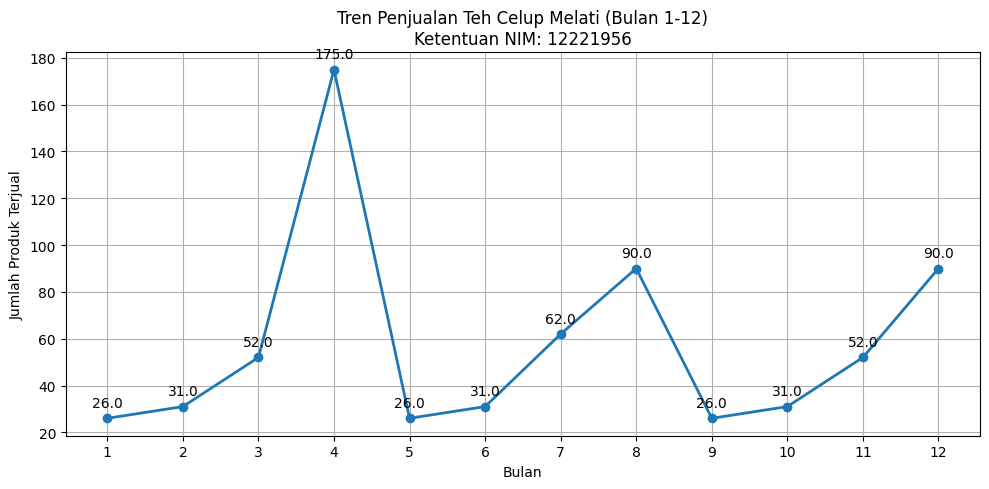

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca dataset
url_yk = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_yk.csv"
url_mgl = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_mgl.csv"

df_yk = pd.read_csv(url_yk)
df_mgl = pd.read_csv(url_mgl)

# Menggabungkan dataset
df_gabungan = pd.concat([df_yk, df_mgl], ignore_index=True)

# Mengubah kolom tanggal menjadi datetime
df_gabungan['tanggal'] = pd.to_datetime(
    df_gabungan['tanggal'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Mengambil bulan transaksi
df_gabungan['bulan'] = df_gabungan['tanggal'].dt.month

# Filter produk Teh Celup Melati
produk_teh = df_gabungan[
    df_gabungan['nama'] == 'Teh Celup Melati'
]

# Menghitung total penjualan per bulan
penjualan_bulanan = produk_teh.groupby('bulan')['jumlah'].sum()

# Menampilkan hasil
print(penjualan_bulanan)

# Membuat line chart
plt.figure(figsize=(10,5))

plt.plot(
    penjualan_bulanan.index,
    penjualan_bulanan.values,
    marker='o',
    linewidth=2
)

plt.title(
    'Tren Penjualan Teh Celup Melati (Bulan 1-12)\nKetentuan NIM: 12221956'
)

plt.xlabel('Bulan')
plt.ylabel('Jumlah Produk Terjual')

plt.xticks(range(1,13))
plt.grid(True)

# Menampilkan label angka
for i, nilai in enumerate(penjualan_bulanan.values):
    plt.annotate(
        str(nilai),
        (penjualan_bulanan.index[i],
         penjualan_bulanan.values[i]),
        textcoords="offset points",
        xytext=(0,8),
        ha='center'
    )

plt.tight_layout()
plt.show()